# Netflix Data Analysis Project

## Project Objective
This project analyzes the Netflix dataset using Python, Pandas, and Matplotlib to uncover insights about content distribution, release trends, genres, countries, and audience classification.


## Import Required Libraries

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Load Dataset

In [11]:
df = pd.read_csv('netflix_titles.csv')

## Dataset Overview

In [12]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [14]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [15]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [16]:
# Check missing values in each column
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


## Data Cleaning

In [18]:
# Standardize country naming by replacing 'United States' with 'USA'
df.loc[df['country'] == 'United States', 'country'] = 'USA'

In [19]:
# Create a cleaner country column using only the first listed country
df['country_clean'] = df['country'].str.split(',').str[0].str.strip()
print(df)

     show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast       country  \
0                                                   NaN           USA   
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...  South Africa   


In [20]:
# Create a new column categorizing content as Adult or Non-Adult
df['content_type'] = df['rating'].apply(lambda x: 'Adult' if x in ['R', 'NC-17', 'TV-MA'] else 'Non-Adult')
print(df)

     show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast       country  \
0                                                   NaN           USA   
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...  South Africa   


## Exploratory Data Analysis

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


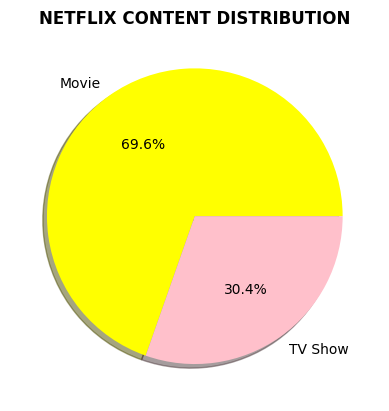

In [21]:
# Analyse movie vs TV show distribution
type_count=df['type'].value_counts()
print(type_count)

colors=['yellow', 'pink']
plt.pie(type_count.values, labels=type_count.index, autopct='%1.1f%%', colors=colors, shadow=True)
plt.title('NETFLIX CONTENT DISTRIBUTION', fontweight='bold')

plt.show()

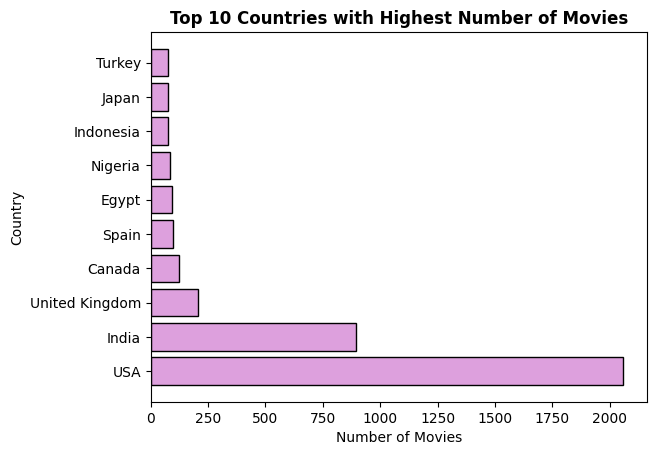

In [22]:
# Find the top 10 countries with the highest number of movies produced
movies = df[df['type'] == 'Movie']

countmovies = movies.groupby('country')['title'].count()

top_movies = countmovies.sort_values(ascending=False).head(10)
plt.barh(top_movies.index, top_movies.values, color='plum', edgecolor='black')
plt.title('Top 10 Countries with Highest Number of Movies', fontweight='bold')
plt.xlabel('Number of Movies')
plt.ylabel('Country')
plt.show()

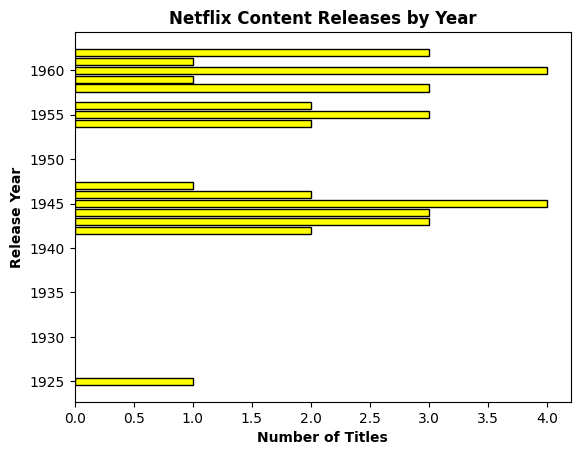

In [23]:
# Analyse content releases year-wise in chronological order
release = df['release_year'].value_counts().sort_index().head(15)

plt.barh(release.index, release.values, color='yellow', edgecolor='black')
plt.title('Netflix Content Releases by Year', fontweight='bold')

plt.xlabel('Number of Titles', fontweight='bold')
plt.ylabel('Release Year', fontweight='bold')

plt.show()

In [24]:
# Display the 10 most recently released titles with country information
top_movies = df.sort_values(by='release_year', ascending=False)

top_movies.loc[::, ['title', 'release_year', 'country']].head(10)

,title,release_year,country
1,Blood & Water,2021,South Africa
2,Ganglands,2021,NaN
3,Jailbirds New Orleans,2021,NaN
31,Chicago Party Aunt,2021,NaN
30,Ankahi Kahaniya,2021,NaN
25,Love on the Spectrum,2021,Australia
23,Go! Go! Cory Carson: Chrissy Takes the Wheel,2021,NaN
20,Monsters Inside: The 24 Faces of Billy Milligan,2021,NaN
19,Jaguar,2021,NaN
18,Intrusion,2021,NaN


In [25]:
# Filter Indian TV shows released from 2020 onwards
shows=df[(df['type']=='TV Show') & (df['country'].str.contains('India', na=False)) & (df['release_year']>=2020)].head(20)
print(shows)

     show_id     type                               title  \
4         s5  TV Show                        Kota Factory   
39       s40  TV Show                        Chhota Bheem   
266     s267  TV Show                The Creative Indians   
297     s298  TV Show                            Navarasa   
876     s877  TV Show                        Alma Matters   
918     s919  TV Show                      Lava Ka Dhaava   
1060   s1061  TV Show                  Indian Matchmaking   
1075   s1076  TV Show   My Love: Six Stories of True Love   
1093   s1094  TV Show                         The Big Day   
1227   s1228  TV Show                       Bombay Begums   
1282   s1283  TV Show                    Zindagi in Short   
1293   s1294  TV Show                       Pitta Kathalu   
1429   s1430  TV Show  Mighty Little Bheem: Kite Festival   
1489   s1490  TV Show                    Regiment Diaries   
1520   s1521  TV Show                     Paava Kadhaigal   
1589   s1590  TV Show   

In [26]:
# Show the top 20 most common genres/categories
df['listed_in'].value_counts().head(20)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


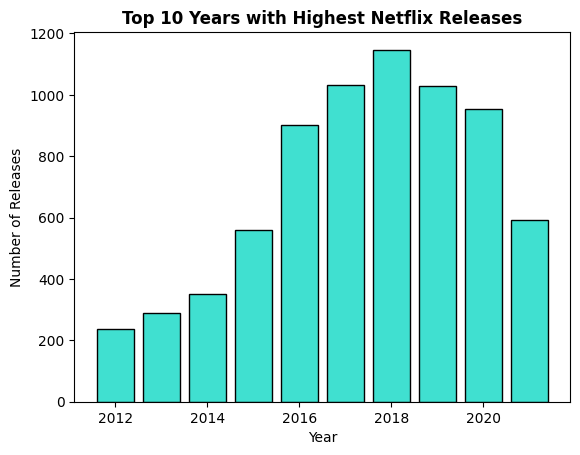

In [27]:
# Show years with the highest number of releases
top_years = df['release_year'].value_counts().head(10)

plt.bar(top_years.index, top_years.values, color='turquoise', edgecolor='black')
plt.title('Top 10 Years with Highest Netflix Releases', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Releases')

plt.show()

In [28]:
# Filter content classified as adult/mature based on ratings
adult_ratings = ['R', 'NC-17', 'TV-MA']
adult_content=df[df['rating'].isin(adult_ratings)]
print(adult_content)

     show_id     type                  title                 director  \
1         s2  TV Show          Blood & Water                      NaN   
2         s3  TV Show              Ganglands          Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans                      NaN   
4         s5  TV Show           Kota Factory                      NaN   
5         s6  TV Show          Midnight Mass            Mike Flanagan   
...      ...      ...                    ...                      ...   
8791   s8792    Movie            Young Adult            Jason Reitman   
8798   s8799    Movie               Zed Plus  Chandra Prakash Dwivedi   
8801   s8802    Movie                Zinzana          Majid Al Ansari   
8802   s8803    Movie                 Zodiac            David Fincher   
8804   s8805    Movie             Zombieland          Ruben Fleischer   

                                                   cast  \
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   
2    

In [29]:
# Identify countries producing the highest amount of adult-rated content
adult_ratings = ['R', 'NC-17', 'TV-MA']
adult_content=df[df['rating'].isin(adult_ratings)]
counter=adult_content['country'].value_counts().head(20)
print(counter)

country
USA                              1369
India                             249
United Kingdom                    210
Spain                             121
Japan                              87
South Korea                        85
France                             82
Mexico                             81
Canada                             78
Turkey                             63
Brazil                             50
Germany                            46
Nigeria                            41
Thailand                           40
Argentina                          40
Australia                          40
United Kingdom, United States      38
Taiwan                             34
Italy                              31
Egypt                              29
Name: count, dtype: int64


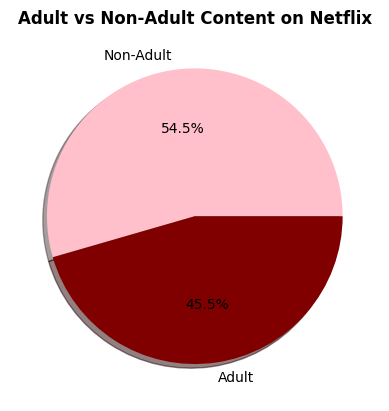

In [30]:
# Adult vs Non-Adult Content Distribution
adult_count = df['content_type'].value_counts()

plt.pie(adult_count.values, labels=adult_count.index, autopct='%1.1f%%', colors=['pink', 'maroon'], shadow=True)

plt.title('Adult vs Non-Adult Content on Netflix', fontweight='bold')

plt.show()

In [31]:
# Display adult-rated titles with their country information
df.loc[df['rating'] == 'TV-MA', ['title', 'country']].head(20)

,title,country
1,Blood & Water,South Africa
2,Ganglands,NaN
3,Jailbirds New Orleans,NaN
4,Kota Factory,India
5,Midnight Mass,NaN
7,Sankofa,"United States, Ghana, Burkina Faso, United Kin..."
10,"Vendetta: Truth, Lies and The Mafia",NaN
11,Bangkok Breaking,NaN
12,Je Suis Karl,"Germany, Czech Republic"
14,Crime Stories: India Detectives,NaN


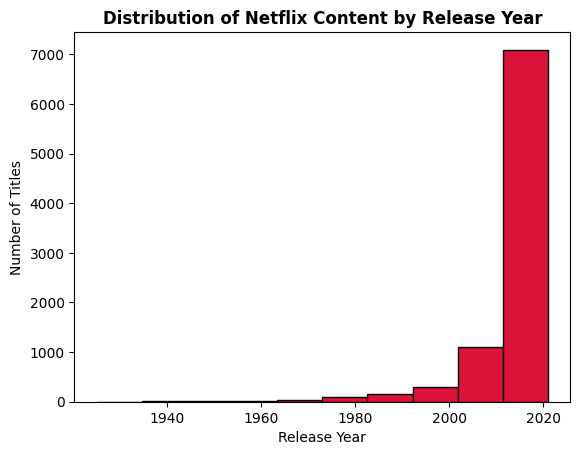

In [32]:
# Most Netflix content in the dataset was released in recent years, indicating a strong concentration of modern titles.
plt.hist(df['release_year'], bins=10, color= 'crimson', edgecolor='black')

plt.title('Distribution of Netflix Content by Release Year', fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

In [35]:
# Compare the number of movies and TV shows by country
df.groupby(['country_clean', 'type'])['title'].count()

country_clean  type   
               Movie       1
               TV Show     1
Argentina      Movie      56
               TV Show    20
Australia      Movie      61
                          ..
Uruguay        TV Show     1
Venezuela      Movie       2
Vietnam        Movie       7
West Germany   Movie       1
Zimbabwe       Movie       1
Name: title, Length: 140, dtype: int64

## Conclusion

- Netflix contains significantly more movies than TV shows.
- Most content has been released in recent years.
- A few countries dominate content production.
- Adult-rated content forms a smaller share.